---
<a id='week4'></a>
# Week 4 — Time-Series Forecasting with ETS(A,Ad,N) — Holt's Damped Trend

**Learning Objective:** Apply ETS(A,Ad,N) to generate multi-year emissions forecasts with confidence intervals; understand why a damped trend model is well-suited to long-range annual emissions data.

> **Model rationale (v3):** ARIMA has been replaced by ETS(A,Ad,N) — Holt's Damped Trend. The damping parameter φ prevents unbounded trend extrapolation over a 20-year horizon, which is more physically realistic for emissions data — particularly for countries with documented slowdowns (UK, Germany). It also requires fewer modelling decisions: no stationarity testing, no ACF/PACF order selection.

> **Index note:** Work with integer-indexed pandas Series (indexed by `year`). `fit.forecast(steps)` returns a `pd.Series` whose index continues from the last training year (2018), so the first forecast value has index 2019.

### Setup — Reload Data

This notebook runs independently of Week 3. Reload the filtered actuals (`ghg_filtered.csv`) used to fit ETS, rebuild the train/test split from `ghg_features.csv` using the same logic as §3.2 (needed for the holdout overlay and §4.6 validation), and load Week 3's regression comparison table to extend with ETS results in §4.6.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from constants import *

EXPANDED_COUNTRIES = get_expanded_countries()

df_filtered = pd.read_csv('../data/ghg_filtered.csv')

df_features = pd.read_csv('../data/ghg_features.csv')
df_model = (
    df_features[['country', 'year'] + FEATURES + [TARGET]]
    .dropna()
    .reset_index(drop=True)
)
train = df_model[df_model['year'] <= TRAIN_CUTOFF]
test  = df_model[df_model['year'] >  TRAIN_CUTOFF]

df_comparison = pd.read_csv('../data/model_comparison_regression.csv', index_col='country')

<a id='41-concept'></a>
### 4.1 Concept Introduction

ETS(A,Ad,N) is a **state space model** that updates three components recursively from each new observation — no feature matrix is required. It differs from the Week 3 regression models in that it uses only the target series itself (CO₂ over time), not engineered lag or rolling-mean features.

| Component | Symbol | What it means |
|-----------|--------|---------------|
| Error | E = A (Additive) | Forecast errors are added to the state, not multiplied |
| Trend | T = Ad (Additive Damped) | Trend grows additively but decays toward zero via damping parameter φ (0 < φ < 1) |
| Seasonality | S = N (None) | Annual data has no within-year seasonal cycle to model |

**Why ETS(A,Ad,N) is appropriate for annual emissions data:**
- No within-year seasonality to model — unlike monthly energy data, annual CO₂ has no calendar cycle
- Damped trend prevents unbounded long-range projections — unlike a unit-root ARIMA, which extrapolates a constant trend indefinitely; after 20 years an undamped model produces physically implausible values
- Works reliably with ~30 data points and has fewer free parameters than ARIMA (no order selection, no stationarity testing required)
- Physically sensible: emissions in real economies tend to slow, plateau, or gradually reverse as energy efficiency improves and policy constraints tighten — not grow at a constant rate indefinitely

**What each fitted parameter represents:**

- **α (smoothing level):** weight given to the most recent observation vs the smoothed history. High α → the model is highly responsive to recent data and "forgets" older observations quickly. Low α → the level estimate is a long-run average.
- **β\* (smoothing trend):** weight given to the most recent trend estimate. High β\* → the trend reacts quickly to recent slope changes. Near zero → the trend is stable and slow to update.
- **φ (damping):** controls how quickly the trend decays toward zero over the forecast horizon. φ near 1 → near-linear extrapolation (trend persists). φ near 0 → trend fades out rapidly and the forecast flattens to a constant level. For most countries φ will be estimated close to 1 by the optimiser, reflecting that emissions trends have been persistent over 1990–2018, but the damping still prevents indefinite linear extrapolation over a 20-year horizon.

<a id='42-model-fitting'></a>
### 4.2 Model Fitting

For each of the ~40 expanded countries, fit `ExponentialSmoothing` on the **1990–2018 training series**:

```python
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
    train_co2,        # pandas Series indexed by integer year
    trend='add',
    damped_trend=True,
    seasonal=None
)
fit = model.fit(optimized=True)
```

After fitting, for **at least 3 countries**:
- Print **α** (`fit.params['smoothing_level']`), **β\*** (`fit.params['smoothing_trend']`), and **φ** (`fit.params['damping_trend']`)
- Store each `fit` object in a dictionary keyed by country name for use in §4.3

**✏️ Interpret:** For the 3 countries you printed, what does a high vs low φ value imply about that country's projected emissions trajectory?

*Write your interpretation here.*

In [2]:
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
from statsmodels.tsa.holtwinters import ExponentialSmoothing

PLOT_COUNTRIES_ETS = ['China', 'United Kingdom', 'India']

ets_fits = {}

with warnings.catch_warnings():
    warnings.simplefilter('ignore', ValueWarning)
    for country in EXPANDED_COUNTRIES:
        series = (
            df_filtered[
                (df_filtered['country'] == country) &
                (df_filtered['year'] <= TRAIN_CUTOFF)
            ]
            .sort_values('year')
            .set_index('year')['co2']
        )
        model = ExponentialSmoothing(series, trend='add', damped_trend=True, seasonal=None)
        ets_fits[country] = model.fit(optimized=True)

print(f"{'Country':<22}  {'α (level)':>10}  {'β* (trend)':>10}  {'φ (damping)':>11}")
print('-' * 58)
for country in PLOT_COUNTRIES_ETS:
    p = ets_fits[country].params
    print(
        f"{country:<22}  "
        f"{p['smoothing_level']:>10.4f}  "
        f"{p['smoothing_trend']:>10.4f}  "
        f"{p['damping_trend']:>11.4f}"
    )


Country                  α (level)  β* (trend)  φ (damping)
----------------------------------------------------------
China                       0.9955      0.7040       0.9710
United Kingdom              0.5215      0.3995       0.9757
India                       0.6392      0.6388       0.9950


Export the fitted ETS smoothing parameters (α, β\*, φ) for **all expanded-set countries** — not just the 3 shown above — to CSV for use in the Streamlit dashboard.

In [3]:
# Export ETS fitted parameters (all expanded countries) to CSV for Streamlit dashboard
rows = []
for country in EXPANDED_COUNTRIES:
    p = ets_fits[country].params
    rows.append({
        'country':   country,
        'alpha':     round(float(p['smoothing_level']), 4),
        'beta_star': round(float(p['smoothing_trend']), 4),
        'phi':       round(float(p['damping_trend']), 4),
    })
df_ets_params = pd.DataFrame(rows)
df_ets_params.to_csv('../data/ets_parameters.csv', index=False)
print(f"Exported ets_parameters.csv — {len(df_ets_params)} rows")
display(df_ets_params)

Exported ets_parameters.csv — 40 rows


,country,alpha,beta_star,phi
0,Algeria,0.6604,0.1877,0.9950
1,Argentina,1.0000,0.0000,0.9646
2,Australia,1.0000,0.6352,0.8914
3,Bangladesh,0.8498,0.2756,0.9950
4,Brazil,1.0000,0.0000,0.9700
5,Canada,0.8380,0.0000,0.9240
6,China,0.9955,0.7040,0.9710
7,Egypt,0.3327,0.0000,0.9950
8,France,0.6812,0.1715,0.8902
9,Germany,0.0000,0.0000,0.9687


<a id='43-forecasting'></a>
### 4.3 Forecasting to 2043

For each of the ~40 expanded countries:
1. Generate out-of-sample forecasts from **2019 to `FORECAST_END`** (2043).
2. Include **95% confidence intervals** via simulation.
3. Store each country's forecast Series and CI bounds in a dict for use in §4.5, §4.6, and
   the CSV exports — every expanded-set country needs a forecast here, since `app.py`/`api/`
   let a user look up any of them.
4. Then produce a forecast plot for the 10 `FEATURED_COUNTRIES` only, in a fixed 5×2 grid
   (same reasoning as §3.8 in Week 3 — a 40-panel grid would not be readable), showing four
   elements with distinct colours:
   - Historical actuals 1990–2018
   - In-sample fitted values
   - 2019–2023 holdout actuals overlaid (for visual validation)
   - Out-of-sample forecast 2019–2043 with CI shading

**Reference:**
```python
steps = FORECAST_END - TRAIN_CUTOFF   # = 25 (covers 2019–2043)
fc_mean = fit.forecast(steps)         # pd.Series indexed 2019…2043

# Confidence intervals via simulation (HoltWintersResults has no get_forecast)
sim = fit.simulate(nsimulations=steps, repetitions=1000, error='add')
ci_lower = sim.quantile(0.025, axis=1)
ci_upper = sim.quantile(0.975, axis=1)

# Store for §4.5 and §5.2
forecasts[country] = {'mean': fc_mean, 'ci_lower': ci_lower, 'ci_upper': ci_upper}
```

> Use `ax.fill_between(fc_mean.index, ci_lower, ci_upper, alpha=0.2)` for CI shading.

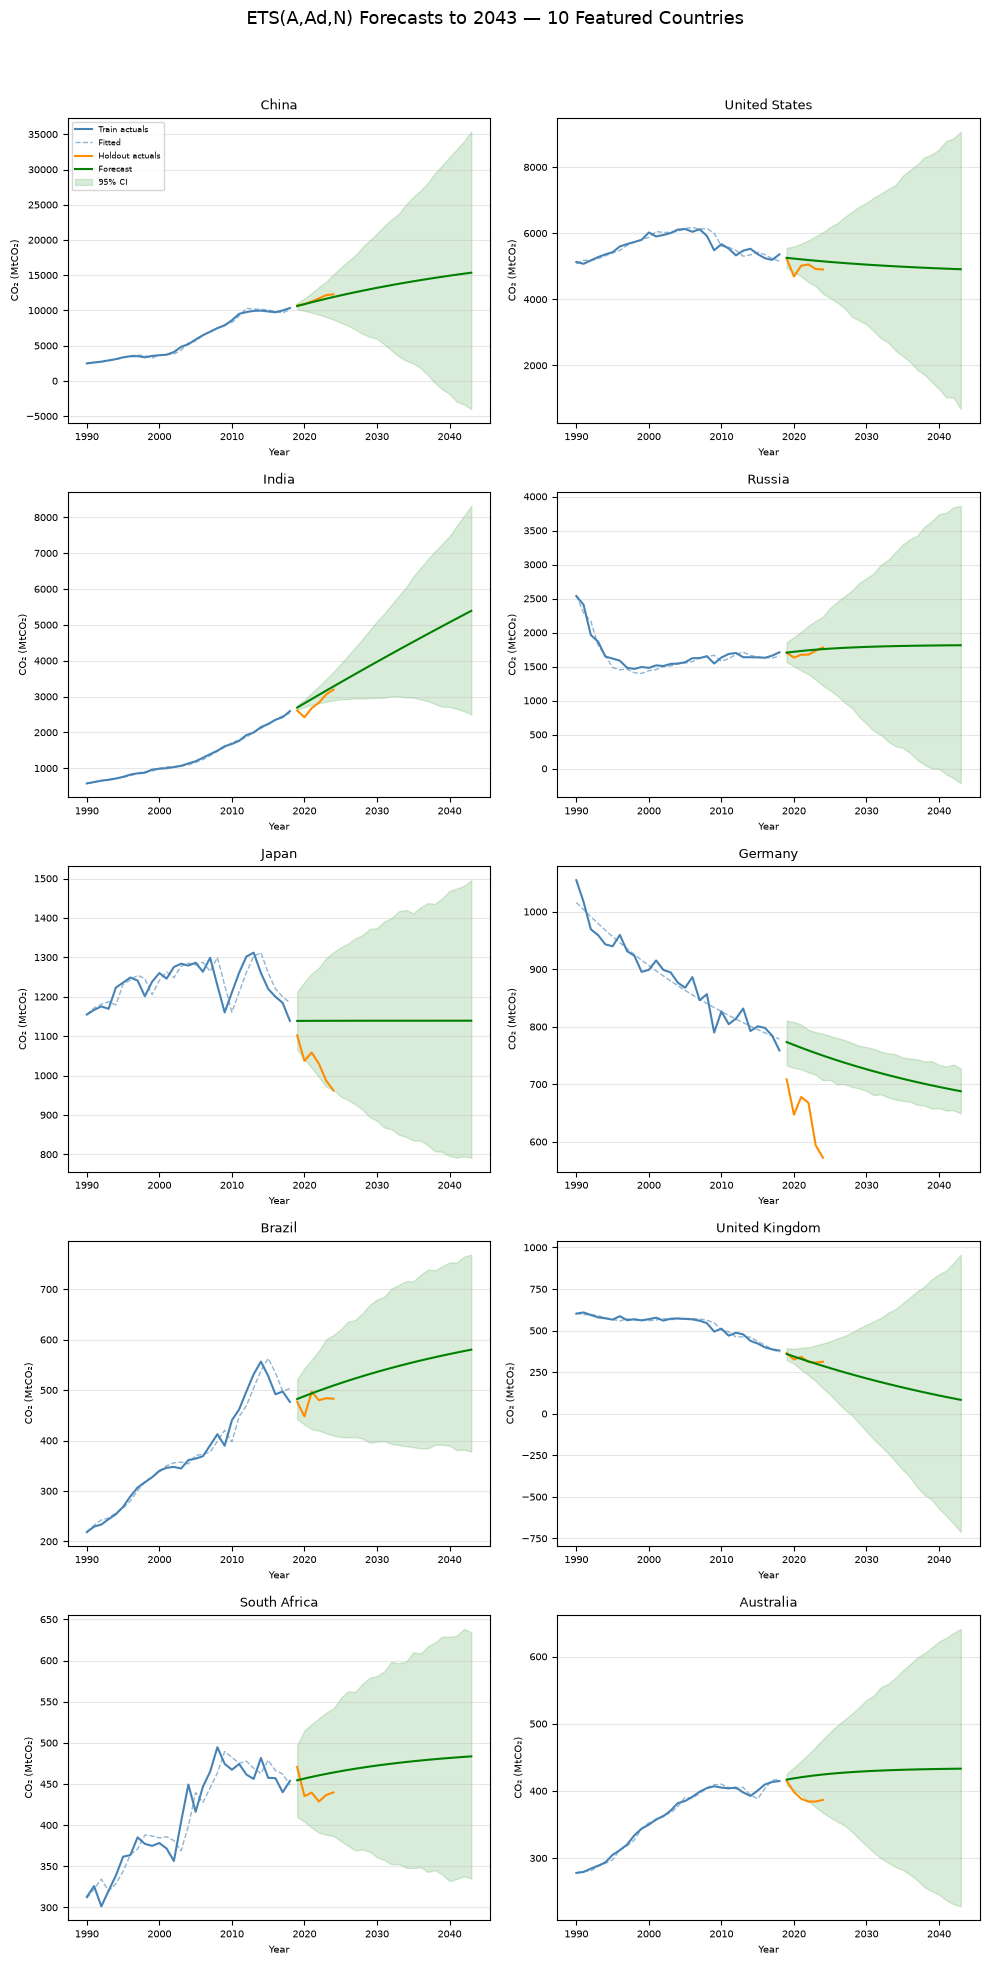

In [4]:
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning

forecasts = {}
steps = FORECAST_END - TRAIN_CUTOFF   # 25 steps: 2019–2043

# Compute forecasts + 95% CI for every expanded-set country — needed downstream by §4.5
# (forecast summary table), §4.6 (five-model comparison, all countries), and the CSV
# exports (ets_forecasts.csv, model_comparison.csv) that api/ and app.py read for any
# country a user selects, not just the 10 FEATURED_COUNTRIES.
for country in EXPANDED_COUNTRIES:
    fit = ets_fits[country]

    with warnings.catch_warnings():
        warnings.simplefilter('ignore', ValueWarning)
        warnings.simplefilter('ignore', FutureWarning)
        fc_mean = fit.forecast(steps)
        sim     = fit.simulate(nsimulations=steps, repetitions=1000, error='add')
    ci_lo   = sim.quantile(0.025, axis=1)
    ci_hi   = sim.quantile(0.975, axis=1)

    forecast_years = np.arange(TRAIN_CUTOFF + 1, FORECAST_END + 1)
    fc_mean.index = forecast_years
    ci_lo.index   = forecast_years
    ci_hi.index   = forecast_years

    forecasts[country] = {'mean': fc_mean, 'ci_lower': ci_lo, 'ci_upper': ci_hi}

# Plot only FEATURED_COUNTRIES (10) in a fixed 5x2 grid — same reasoning as §3.8's RF
# recursive-forecast grid in Week 3. All ~40 countries' forecasts are already computed
# above and available in `forecasts` for every downstream use.
fig, axes = plt.subplots(5, 2, figsize=(10, 20))
axes_flat = axes.flatten()

for ax, country in zip(axes_flat, FEATURED_COUNTRIES):
    fit    = ets_fits[country]
    series = (
        df_filtered[df_filtered['country'] == country]
        .sort_values('year').set_index('year')['co2']
    )
    test_c = test[test['country'] == country].set_index('year')['co2']
    fc_mean = forecasts[country]['mean']
    ci_lo   = forecasts[country]['ci_lower']
    ci_hi   = forecasts[country]['ci_upper']

    train_s = series[series.index <= TRAIN_CUTOFF]
    fitted  = fit.fittedvalues

    ax.plot(train_s.index, train_s,  color='steelblue',  lw=1.5, label='Train actuals')
    ax.plot(fitted.index,  fitted,   color='steelblue',  lw=1,   ls='--', alpha=0.6, label='Fitted')
    ax.plot(test_c.index,  test_c,   color='darkorange', lw=1.5, label='Holdout actuals')
    ax.plot(fc_mean.index, fc_mean,  color='green',      lw=1.5, label='Forecast')
    ax.fill_between(fc_mean.index, ci_lo, ci_hi, color='green', alpha=0.15, label='95% CI')
    ax.set_title(country, fontsize=9)
    ax.set_xlabel('Year', fontsize=7)
    ax.set_ylabel('CO₂ (MtCO₂)', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(axis='y', alpha=0.3)

axes_flat[0].legend(fontsize=6, loc='upper left')
plt.suptitle(f'ETS(A,Ad,N) Forecasts to 2043 — {len(FEATURED_COUNTRIES)} Featured Countries', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


<a id='44-trend'></a>
### 4.4 Trend Interpretation

The three showcase countries — China, United Kingdom, and India — illustrate the three qualitatively different trajectory types visible across the expanded country panel.

---

**China** (α = 0.9955, β\* = 0.7040, φ = 0.9710)

China's near-unity α means the model almost entirely discards history when updating the level: each new observation dominates. The high β\* (0.704) lets the trend react strongly to year-over-year acceleration or deceleration. The damping factor φ = 0.971 is moderate — compounded over the 25-year horizon, annual trend increments shrink to roughly (0.971²⁵ ≈ 0.48) of their 2018 value, so growth continues but at progressively slower pace. The model projects emissions rising from 10,897 MtCO₂ (2020) to 14,932 MtCO₂ by 2040 (+37 %). This is broadly consistent with China's stated "peak before 2030" target: the damped trend structurally decelerates through the 2020s without requiring an explicit policy break-point. The 95 % CI is wide in absolute terms by 2040 (China's scale amplifies forecast uncertainty), and the ETS MAE on the 2019–2023 holdout is 234.5 MtCO₂ — better than both RF variants for China but behind Linear Regression (64.3 MtCO₂).

---

**United Kingdom** (α = 0.5215, β\* = 0.3995, φ = 0.9757)

The UK's moderate α and lower β\* produce a smoother, less reactive fit: recent structural shifts in the energy mix (coal phase-out, gas decline, renewables growth) are incorporated gradually rather than spike-by-spike. φ = 0.976 is similar to China's, so the declining trend also attenuates — by 2040, annual reductions are roughly (0.976²⁵ ≈ 0.54) of their 2018 rate — but because the underlying trend is *negative*, damping means the decline slows rather than stopping. The projection falls from 326.3 MtCO₂ (2020) to 109.8 MtCO₂ by 2040 (−66 %), broadly in line with the UK's legally binding 78 % reduction target by 2035 under the Climate Change Act. Absolute CI widths are the narrowest of the three countries, reflecting the lower emission scale and more predictable policy trajectory. ETS achieves a respectable MAE here (12.0 MtCO₂), beating the Baseline (18.2) and RF Per-Country (60.2) — but at the expanded, ~40-country scale, the *pooled* Random Forest now edges out both ETS and LR for the UK specifically (RF MAE 6.2 vs LR 8.9 vs ETS 12.0), a reversal from the original 10-country scale where LR led every country. More pooled training data (other countries' declining-trend patterns) appears to help the ensemble generalize to the UK's own structural decline better than either a purely country-specific linear fit or a purely UK-specific trend-smoothing model.

---

**India** (α = 0.6392, β\* = 0.6388, φ = 0.9950)

India's φ = 0.995 is nearly 1 — effectively no damping over any practical horizon. After 25 steps the trend has decayed to only (0.995²⁵ ≈ 0.88) of its starting value, meaning India's growth rate in the model is almost constant through 2043. This produces the most aggressive projection: emissions nearly double from 2,422.7 MtCO₂ (2020) to 5,071.0 MtCO₂ by 2040 (+109 %), making India the second-largest emitter in the forecast by 2030. The near-undamped trend also generates the widest 95 % CI of the three countries by 2040: if India's rapid renewable-energy buildout bends the emissions curve before the model horizon, the actual outcome could fall well below the central forecast. The ETS holdout MAE of 189.0 MtCO₂ reflects the difficulty of forecasting high-growth economies with a purely statistical model that cannot anticipate policy discontinuities.


<a id='45-forecast-table'></a>
### 4.5 Forecast Summary Table

Extract point forecast values for **2030, 2035, and 2040** from each country's `forecasts[country]['mean']` (the `pd.Series` stored in §4.3). Look up the **2020 actual** CO₂ from `df_filtered`. Build a summary DataFrame:

```
Country | 2030 Forecast (MtCO₂) | 2035 Forecast | 2040 Forecast | 2020 Actual | % Change 2020→2040
```

Round forecast values to 1 decimal place and sort by 2040 forecast (descending).

In [5]:
rows = []
for country in EXPANDED_COUNTRIES:
    fc_mean     = forecasts[country]['mean']
    actual_2020 = df_filtered[
        (df_filtered['country'] == country) & (df_filtered['year'] == 2020)
    ]['co2'].values[0]
    fc_2040     = round(fc_mean.loc[2040], 1)
    pct_change  = round((fc_2040 - actual_2020) / actual_2020 * 100, 1)
    rows.append({
        'Country':                country,
        '2030 Forecast (MtCO₂)': round(fc_mean.loc[2030], 1),
        '2035 Forecast':          round(fc_mean.loc[2035], 1),
        '2040 Forecast':          round(fc_mean.loc[2040], 1),
        '2020 Actual':            round(actual_2020, 1),
        '% Change 2020→2040':     pct_change,
    })

df_forecast_summary = (
    pd.DataFrame(rows)
    .set_index('Country')
    .sort_values('2040 Forecast', ascending=False)
)
display(df_forecast_summary)

,2030 Forecast (MtCO₂),2035 Forecast,2040 Forecast,2020 Actual,% Change 2020→2040
Country,,,,,
China,13208.8,14133.7,14932.1,10896.5,37.0
India,3969.8,4527.3,5071.0,2422.7,109.3
United States,5052.0,4988.2,4937.6,4690.0,5.3
Russia,1789.2,1803.3,1811.0,1631.9,11.0
Japan,1139.1,1139.2,1139.2,1037.3,9.8
Iran,862.6,933.8,1002.8,745.6,34.5
Saudi Arabia,832.8,904.8,974.9,653.6,49.2
Indonesia,765.0,832.4,898.1,623.3,44.1
South Korea,753.1,778.5,799.8,597.6,33.8


<a id='46-validation'></a>
### 4.6 Model Validation

1. Compute MAE and RMSE of ETS(A,Ad,N) forecasts against the **2019–2023 holdout actuals** for each country.
2. **Extend the §3.7 comparison table** to add `ETS MAE` and `ETS RMSE`, completing the five-model consolidated comparison:

```
Country | Baseline MAE | LR MAE | RF-PC MAE | RF MAE | ETS MAE | Baseline RMSE | LR RMSE | RF-PC RMSE | RF RMSE | ETS RMSE | Best Model
```


In [6]:
ets_results = {}

for country in EXPANDED_COUNTRIES:
    test_c  = test[test['country'] == country]
    if test_c.empty:
        continue
    fc_mean = forecasts[country]['mean']
    y_pred  = fc_mean.loc[test_c['year'].values].values
    y_true  = test_c[TARGET].values
    ets_results[country] = {
        'ETS MAE':  round(mean_absolute_error(y_true, y_pred), 1),
        'ETS RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 1),
    }

df_ets = pd.DataFrame(ets_results).T
df_comparison_full = df_comparison.join(df_ets)

mae_cols_full = ["Baseline MAE", "LR MAE", "RF-PC MAE", "RF MAE", "ETS MAE"]
df_comparison_full["Best Model"] = (
    df_comparison_full[mae_cols_full].idxmin(axis=1)
    .str.replace(" MAE", "", regex=False)
)

print("Five-model comparison — Naive Baseline · LR · RF Per-Country · RF Pooled · ETS(A,Ad,N):")
display(df_comparison_full.sort_index())

Five-model comparison — Naive Baseline · LR · RF Per-Country · RF Pooled · ETS(A,Ad,N):


,Baseline MAE,Baseline RMSE,LR MAE,LR RMSE,RF-PC MAE,RF-PC RMSE,RF MAE,RF RMSE,Best Model,ETS MAE,ETS RMSE
country,,,,,,,,,,,
Algeria,9.3,9.6,2.9,4.4,18.2,21.2,1.5,2.1,RF,6.6,7.9
Argentina,10.4,13.1,1.6,1.9,8.8,10.6,2.9,4.3,LR,10.4,12.7
Australia,5.6,8.1,0.7,0.8,13.7,14.8,1.8,2.0,LR,28.1,31.1
Bangladesh,3.6,4.3,4.1,4.5,15.1,15.8,0.7,0.8,RF,1.3,1.8
Brazil,16.5,24.1,3.1,3.8,15.1,19.4,4.9,6.7,LR,19.0,22.7
Canada,16.1,24.0,0.6,0.7,19.3,20.8,7.7,8.3,LR,34.2,37.4
China,323.7,348.0,64.3,76.8,1328.2,1457.4,1357.9,1484.7,LR,234.5,294.5
Egypt,11.0,12.8,3.8,4.3,8.6,10.8,4.6,5.2,LR,20.7,22.8
France,18.4,21.3,4.1,5.0,42.0,46.1,7.3,8.8,LR,28.9,33.2


---
## Week 6 — Data Exports for Streamlit Dashboard

Run the two cells below after completing §4.6 to generate the CSV files
required by `app.py`:
- `data/ets_forecasts.csv` — ETS forecast means and 95% CI bounds (2019–2043)
- `data/model_comparison.csv` — Five-model MAE/RMSE comparison table


In [7]:
# Export ETS forecasts to CSV for Streamlit dashboard
rows = []
for country in EXPANDED_COUNTRIES:
    for yr, mean_val in forecasts[country]['mean'].items():
        rows.append({
            'country':  country,
            'year':     int(yr),
            'mean':     round(float(mean_val), 3),
            'ci_lower': round(float(forecasts[country]['ci_lower'].loc[yr]), 3),
            'ci_upper': round(float(forecasts[country]['ci_upper'].loc[yr]), 3),
        })
df_ets_export = pd.DataFrame(rows)
df_ets_export.to_csv('../data/ets_forecasts.csv', index=False)
print(f"Exported ets_forecasts.csv — {len(df_ets_export)} rows")
display(df_ets_export.head())

Exported ets_forecasts.csv — 1000 rows


,country,year,mean,ci_lower,ci_upper
0,Algeria,2019,179.063,163.471,194.060
1,Algeria,2020,184.827,165.202,204.001
2,Algeria,2021,190.562,165.498,213.795
3,Algeria,2022,196.269,164.780,226.651
4,Algeria,2023,201.947,163.971,238.713


In [8]:
# Export five-model comparison table to CSV for Streamlit dashboard
df_comparison_full.reset_index().rename(columns={'index': 'country'}).to_csv(
    '../data/model_comparison.csv', index=False
)
print("Exported model_comparison.csv")
display(df_comparison_full)

Exported model_comparison.csv


,Baseline MAE,Baseline RMSE,LR MAE,LR RMSE,RF-PC MAE,RF-PC RMSE,RF MAE,RF RMSE,Best Model,ETS MAE,ETS RMSE
country,,,,,,,,,,,
Algeria,9.3,9.6,2.9,4.4,18.2,21.2,1.5,2.1,RF,6.6,7.9
Argentina,10.4,13.1,1.6,1.9,8.8,10.6,2.9,4.3,LR,10.4,12.7
Australia,5.6,8.1,0.7,0.8,13.7,14.8,1.8,2.0,LR,28.1,31.1
Bangladesh,3.6,4.3,4.1,4.5,15.1,15.8,0.7,0.8,RF,1.3,1.8
Brazil,16.5,24.1,3.1,3.8,15.1,19.4,4.9,6.7,LR,19.0,22.7
Canada,16.1,24.0,0.6,0.7,19.3,20.8,7.7,8.3,LR,34.2,37.4
China,323.7,348.0,64.3,76.8,1328.2,1457.4,1357.9,1484.7,LR,234.5,294.5
Egypt,11.0,12.8,3.8,4.3,8.6,10.8,4.6,5.2,LR,20.7,22.8
France,18.4,21.3,4.1,5.0,42.0,46.1,7.3,8.8,LR,28.9,33.2


**Discussion — ETS(A,Ad,N) vs the regression models (2019–2023 holdout):**

Across the 40 expanded countries, Linear Regression remains the best model for 28 (70%), with the pooled Random Forest now winning the remaining 12 — the same split found in §3.7, unchanged by adding ETS to the comparison (ETS never wins the 2019–2023 holdout outright). ETS outperforms the naïve Baseline for 9 of 40 countries (Algeria, Argentina, Bangladesh, China, Iraq, Malaysia, Turkey, United Kingdom, Vietnam) and outperforms the pooled Random Forest for only 2 of 40 (China and United States — notably, the UK no longer appears here at the expanded scale: RF Pooled's UK MAE improved enough with more pooled training data to overtake ETS, see §4.4). Against the per-country RF, ETS wins exactly half — 20 of 40. This middling performance is expected: the five-year holdout (2019–2023) coincides with the COVID-19 dip and partial rebound, which are discrete shocks that a trend-smoothing model cannot anticipate. LR's simple linear relationship with `years_since_1990` happens to interpolate through this turbulence well because it has no "memory" of pre-COVID momentum to defend. ETS's strength — the damped trend that prevents unbounded extrapolation — is more visible at longer horizons (§4.5), where the regression models' linear extrapolation becomes physically implausible (e.g. predicting the UK's linear decline reaches zero CO₂ before 2050). For the purpose of 25-year scenario analysis, ETS(A,Ad,N) is the appropriate choice despite its inferior short-horizon holdout scores.


---
> ```
> git add notebook/week4_ets_forecasting.ipynb
> git commit -m "Week 4: ETS(A,Ad,N) Holt Damped forecasting complete"
> git push
> ```